#Run a GC analysis test through a series of genomes. Returns an analysis object with a distribution of codons usage through CDS, viral seqs, and other genomic locations like introns.

#This is the one that runs much faster but requires high RAM

In [1]:
#Mount drive
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dataclasses import dataclass
import json
from google.colab import drive
drive.mount('/content/drive')
%ls
%cd content
%cd drive
%cd MyDrive

%run GeneClassesCloud.ipynb

Mounted at /content/drive
drive/  sample_data/
[Errno 2] No such file or directory: 'content'
/content
/content/drive
/content/drive/MyDrive


In [2]:
#Load all gene objects from firstPassPlusSpliceAI
%ls RefGenes
geneobjs = os.listdir(os.path.join("RefGenes", "NHGeneBodySupp"))
print(geneobjs)


NHGeneBodySupp/
['153579.json', '653140.json', '645051.json', '342357.json', '341568.json', '283111.json', '136263.json', '85280.json', '84616.json', '342926.json', '284274.json', '100505573.json', '645369.json', '145853.json', '283933.json', '256051.json', '144809.json', '643037.json', '284355.json', '256302.json', '245915.json', '138883.json', '126017.json', '79544.json', '26539.json', '338809.json', '140687.json', '386678.json', '342346.json', '337959.json', '285311.json', '143501.json', '245913.json', '80099.json', '729201.json', '653598.json', '643664.json', '494118.json', '442361.json', '400120.json', '353515.json', '140700.json', '139170.json', '116236.json', '283948.json', '728116.json', '644070.json', '140731.json', '79170.json', '105373377.json', '101059953.json', '100133267.json', '100130361.json', '441509.json', '399474.json', '390231.json', '347475.json', '100526772.json', '400451.json', '284418.json', '170370.json', '148103.json', '80045.json', '151649.json', '91120.json'

In [3]:
'''
@dataclass
class CodonPairBiasAnalysis:
  organism: str
  transcriptome: str
  totalCodonPairs: int
  cpbPerGene: list
  cpb_lit: dict
'''

def loadGeneBody(gne):
  gene = None

  with open(gne, 'r') as infile:
      gene = json.load(infile)
  if gene is None:
    print("Gene not found")
  isosList = gene['isoforms']
  geneID = gene['geneID']
  geneName = gene['geneName']
  organism = gene['organism']
  DNASequence = gene['DNASequence']
  spliceAIDonor = gene['spliceAIDonor']
  spliceAIReceptor = gene['spliceAIReceptor']
  ######3
  chromosome = gene['chromosome']

  isoformsObjs = []
  for iso in isosList:
    #print(iso)
    isoformNumber = iso['isoformNumber']
    #
    associatedProteinPC = iso['associatedProtein']
    aaSeq = associatedProteinPC['aaSeq']
    protWeight = associatedProteinPC['protWeight']
    associatedGeneID = associatedProteinPC['associatedGeneID']
    associatedProtein = ProteinObj(aaSeq, protWeight, associatedGeneID)
    #
    fullSequence = iso['fullSequence']
    codingSeq = iso['mRNASeq']
    relativeAbundance = iso['relativeAbundance']
    geneBody = iso['geneBody'] # This variable is already defined
    codons = iso['codons']
    isoformsObjs.append(IsoformGeneBody(isoformNumber, associatedProtein, fullSequence, codingSeq, codons, relativeAbundance, geneBody))
  geneInQuestion = NaturalGene(isoformsObjs, geneID, geneName, organism, DNASequence, spliceAIDonor, spliceAIReceptor, {}, chromosome)
  return geneInQuestion

In [4]:
def gc_analysis(gobj: NaturalGene, aobj: GCAnalysis = None):
  '''
  This functions builds the stats of the analysis object as it runs through gene objects

  @dataclass
  class GCAnalysis:
    organism: str
    transcriptome: str
    totalCodons: int
    windows: dict
    taggedGC1: dict
    taggedGC2: dict
    taggedGC3: dict
    windowsize: int

  '''
  #Create analysis object if there isn't one
  win_dict = {'ExonL50': [], 'Exon': [], 'ExonR50': []}
  ex_dict = {'ExonL50': [], 'Exon': [], 'ExonR50': [], 'Splice': []}
  if aobj is None:
    aobj = GCAnalysis(gobj.organism, 'General Human', 0, win_dict, ex_dict.copy(), ex_dict.copy(), ex_dict.copy(), 21)

  #Aggregate stats for each protein-coding isoform
  for iso in gobj.isoforms:
    #Skip computationally predicted but non-experimentally-validated isoforms
    if 'X' in str(iso.isoformNumber):
      continue
    #Only run stats on protein-coding isoforms
    if iso.associatedProtein is not None:
      codons = iso.codons
      if len(codons) == 0:
        continue
      val = True
      for c in codons:
        if len(c[0]) != 3:
          val = False
          break
      if not val:
        print("Invalid codon stream")
        continue

      #Collect GC, GC1, GC2, and GC3
      tgc1 = {'ExonL50': [], 'Exon': [], 'ExonR50': [], 'Splice': []}
      tgc2 = {'ExonL50': [], 'Exon': [], 'ExonR50': [], 'Splice': []}
      tgc3 = {'ExonL50': [], 'Exon': [], 'ExonR50': [], 'Splice': []}
      for c in codons:
        aobj.totalCodons += 1
        match c[1]:
          case 'S':
            if c[0][0] == 'G' or c[0][0] == 'C':
              tgc1['Splice'].append(1)
            else:
              tgc1['Splice'].append(0)
            if c[0][1] == 'G' or c[0][1] == 'C':
              tgc2['Splice'].append(1)
            else:
              tgc2['Splice'].append(0)
            if c[0][2] == 'G' or c[0][2] == 'C':
              tgc3['Splice'].append(1)
            else:
              tgc3['Splice'].append(0)
          case 'F':
            if c[0][0] == 'G' or c[0][0] == 'C':
              tgc1['ExonL50'].append(1)
            else:
              tgc1['ExonL50'].append(0)
            if c[0][1] == 'G' or c[0][1] == 'C':
              tgc2['ExonL50'].append(1)
            else:
              tgc2['ExonL50'].append(0)
            if c[0][2] == 'G' or c[0][2] == 'C':
              tgc3['ExonL50'].append(1)
            else:
              tgc3['ExonL50'].append(0)
          case 'T':
            if c[0][0] == 'G' or c[0][0] == 'C':
              tgc1['ExonR50'].append(1)
            else:
              tgc1['ExonR50'].append(0)
            if c[0][1] == 'G' or c[0][1] == 'C':
              tgc2['ExonR50'].append(1)
            else:
              tgc2['ExonR50'].append(0)
            if c[0][2] == 'G' or c[0][2] == 'C':
              tgc3['ExonR50'].append(1)
            else:
              tgc3['ExonR50'].append(0)
          case 'I':
            if c[0][0] == 'G' or c[0][0] == 'C':
              tgc1['Exon'].append(1)
            else:
              tgc1['Exon'].append(0)
            if c[0][1] == 'G' or c[0][1] == 'C':
              tgc2['Exon'].append(1)
            else:
              tgc2['Exon'].append(0)
            if c[0][2] == 'G' or c[0][2] == 'C':
              tgc3['Exon'].append(1)
            else:
              tgc3['Exon'].append(0)

      #Process tagged GCs and append to aobj
      for key in aobj.taggedGC1.keys():
        if len(tgc1[key]) == 0:
          continue
        #Get val
        v = np.sum(tgc1[key]) / len(tgc1[key])
        aobj.taggedGC1[key].append(v)

      for key in aobj.taggedGC2.keys():
        if len(tgc2[key]) == 0:
          continue
        #Get val
        v = np.sum(tgc2[key]) / len(tgc2[key])
        aobj.taggedGC2[key].append(v)

      for key in aobj.taggedGC3.keys():
        if len(tgc3[key]) == 0:
          continue
        #Get val
        v = np.sum(tgc3[key]) / len(tgc3[key])
        aobj.taggedGC3[key].append(v)


      #Windows
      win_size = aobj.windowsize
      window_dict = {'ExonL50': [], 'Exon': [], 'ExonR50': []} # Initialize with empty lists
      for i in range(len(iso.geneBody)):
        exlen = len(iso.geneBody[i]['seq'])
        if exlen < aobj.windowsize*3:
          continue

        #print(exlen)
        locs = []
        if exlen < 100:
          for j in range(0,exlen//2):
            locs.append('ExonL50')
          while len(locs) != exlen:
            locs.append('ExonR50')
        else:
          for j in range(0,exlen):
            if j < 50:
              locs.append('ExonL50')
            elif j > exlen - 50:
              locs.append('ExonR50')
            else:
              locs.append('Exon')
        wins = [iso.geneBody[i]['seq'][j:j+win_size] for j in range(0, len(iso.geneBody[i]['seq']) - win_size)]
        locwins = [locs[j:j+win_size] for j in range(0, len(iso.geneBody[i]['seq']) - win_size)]
        for k in range(len(wins)):
          #Figure out how to classify windo based on locwin
          locwin = locwins[k]
          win = wins[k]
          gcwin = [0 if win[j] == 'A' or win[j] == 'T' else 1 for j in range(len(win))]
          gc = np.sum(gcwin) / len(gcwin)
          #Get majority loc from locwin
          loc_counts = {'ExonL50': 0, 'Exon': 0, 'ExonR50': 0} # Changed variable name to avoid conflict
          for l in locwin:
            loc_counts[l] += 1
          maxloc = max(loc_counts, key=loc_counts.get)
          #print(maxloc)
          window_dict[maxloc].append(gc) # Use maxloc (the key) instead of loc_counts[maxloc] (the value)

      #High memory option
      for k in win_dict.keys():
        for i in range(len(window_dict[k])):
          aobj.windows[k].append(window_dict[k][i])


  return aobj

def saveGCAnalysis(aobj: GCAnalysis, filename: str):
  with open(filename, 'w') as outfile:
    json.dump(aobj.__dict__, outfile)

def loadGCAnalysis(filename: str):
  with open(filename, 'r') as infile:
    dta = json.load(infile)
  #Construct dataclass with dta
  c = GCAnalysis(**dta)
  return c


def visualize_gc_analysis(gc_obj):
  '''Take a codon analysis object and visualize the data'''
  #Make a histogram of values from the gc usage

  plt.hist(gc_obj.taggedGC1['ExonL50'], color='blue', alpha=0.5, bins=200)
  plt.hist(gc_obj.taggedGC1['Exon'], color='green', alpha=0.5, bins=200)
  plt.hist(gc_obj.taggedGC1['ExonR50'], color='red', alpha=0.5, bins=200)
  plt.hist(gc_obj.taggedGC1['Splice'], color='yellow', alpha=0.5, bins=200)
  plt.title('GC1')
  plt.show()

  plt.hist(gc_obj.taggedGC2['ExonL50'], color='blue', alpha=0.5, bins=200)
  plt.hist(gc_obj.taggedGC2['Exon'], color='green', alpha=0.5, bins=200)
  plt.hist(gc_obj.taggedGC2['ExonR50'], color='red', alpha=0.5, bins=200)
  plt.hist(gc_obj.taggedGC2['Splice'], color='yellow', alpha=0.5, bins=200)
  plt.title('GC2')
  plt.show()

  plt.hist(gc_obj.taggedGC3['ExonL50'], color='blue', alpha=0.5, bins=200)
  plt.hist(gc_obj.taggedGC3['Exon'], color='green', alpha=0.5, bins=200)
  plt.hist(gc_obj.taggedGC3['ExonR50'], color='red', alpha=0.5, bins=200)
  plt.hist(gc_obj.taggedGC3['Splice'], color='yellow', alpha=0.5, bins=200)
  plt.title('GC3')
  plt.show()

  plt.hist(gc_obj.windows['ExonL50'], color='blue', alpha=0.5, bins=200)
  plt.hist(gc_obj.windows['Exon'], color='green', alpha=0.5, bins=200)
  plt.hist(gc_obj.windows['ExonR50'], color='red', alpha=0.5, bins=200)
  plt.title('Windows')
  plt.show()

Currently written to be performed in a single run. No progress counter as of now.

Invalid codon stream
Invalid codon stream
Invalid codon stream


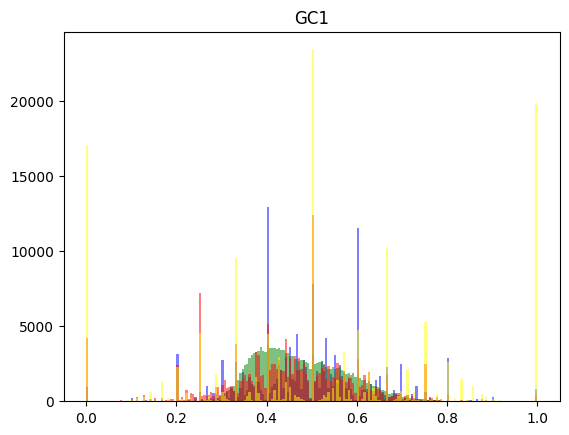

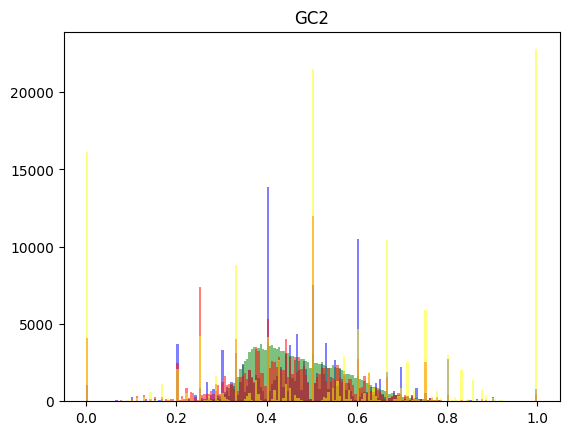

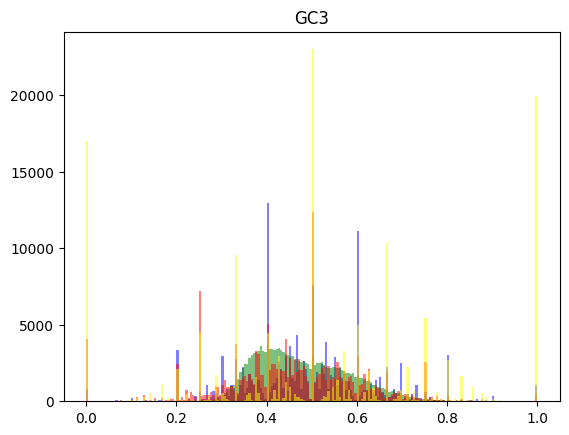

In [ ]:
#Try loading an existing GC analysis
savepath = os.path.join("GeneLit", "GCAnalysis.json")
savepath = os.path.join("Standards", "GCAnalysis.json")
try:
  gcana = loadGCAnalysis(savepath)
except FileNotFoundError:
  print("File not found")
  gcana = None

#Run through the genome(s)
for i in range(len(geneobjs)):
  file_path = os.path.join("RefGenes", "NHGeneBodySupp", geneobjs[i])
  gobj = loadGeneBody(file_path)
  gcana = gc_analysis(gobj, gcana)
  #print(gobj.geneID)
visualize_gc_analysis(gcana)
saveGCAnalysis(gcana, savepath)

In [ ]:
def overall_gcs(gobjs: list[NaturalGene]):
  overall_gc_list = []
  for gobj in gobjs:
    for iso in gobj.isoforms:
      #Skip computationally predicted but non-experimentally-validated isoforms
      if 'X' in str(iso.isoformNumber):
        continue

      #Join the codons to make the full rna
      full_rna = ''
      for i in range(len(iso.geneBody)):
        full_rna += iso.geneBody[i]['seq']
      overall_gc = [0 if full_rna[i] == 'A' or full_rna[i] == 'T' or full_rna[i] == 'U' else 1 for i in range(len(full_rna))]
      overall_gc = np.sum(overall_gc) / len(overall_gc)
      overall_gc_list.append(overall_gc)
  return overall_gc_list


gobjj = []
#Run through the genome(s)
for i in range(len(geneobjs)):
  file_path = os.path.join("RefGenes", "NHGeneBodySupp", geneobjs[i])
  gobj = loadGeneBody(file_path)
  gobjj.append(gobj)
  #print(gobj.geneID)

ov_gc = overall_gcs(gobjj)
plt.hist(ov_gc, color='blue', alpha=0.5, bins=200)
plt.title('Overall GC')
plt.show()